# UNESA Academic Knowledge Graph - Construction Pipeline
**Research Experiment Notebook** | Strwythura-Adapted Architecture

Pipeline ini membangun Knowledge Graph akademik UNESA menggunakan 4 fase:
1. **Structural Layer** - Dosen, Paper, Departemen, Venue
2. **Semantic Layer** - IEEE Thesaurus Taxonomy Mapping
3. **Lexical Layer** - GLiNER NER + Chunking
4. **Embedding Layer** - Vector Embeddings (LanceDB + Word2Vec)

---

## Cell 1: Environment Setup

In [1]:
# !pip install -q supabase rdflib sentence-transformers gliner spacy networkx python-dotenv gensim requests torch lancedb
# !python -m spacy download en_core_web_sm

import os, sys, logging, json, time
from pathlib import Path
from dotenv import load_dotenv

logging.basicConfig(level=logging.INFO, format='%(asctime)s [%(levelname)s] %(name)s: %(message)s', datefmt='%H:%M:%S')
logger = logging.getLogger('KG_Pipeline')

ROOT_DIR = Path('.').resolve()
load_dotenv(ROOT_DIR / 'kg.env')
sys.path.insert(0, str(ROOT_DIR / 'src'))

assert os.environ.get('SUPABASE_URL'), 'SUPABASE_URL not set!'
print('=== Setup Complete ===')

=== Setup Complete ===


## Cell 2: Data Extraction (Incremental)
Fetch data dosen dan paper dari Supabase.

In [2]:
from data_loader import DataLoader

loader = DataLoader()
lecturers = loader.fetch_lecturers()
papers = loader.fetch_papers()
translations = loader.fetch_taxonomy_translations()

print(f'Lecturers: {len(lecturers)} | Papers: {len(papers)} | Translations: {len(translations)}')
if papers:
    p = papers[0]
    print(f'Sample: {p.get("title","")[:60]} | Keywords: {p.get("keywords_clean",[])}')

20:56:23 [INFO] data_loader: Connected to Supabase at https://wfjzdhaaldwyiajbyzln.supabase.co
20:56:23 [INFO] data_loader: Fetching lecturers data from Supabase...
20:56:24 [INFO] httpx: HTTP Request: GET https://wfjzdhaaldwyiajbyzln.supabase.co/rest/v1/lecturers?select=%2A "HTTP/2 200 OK"
20:56:24 [INFO] data_loader: Found 129 lecturers.
20:56:24 [INFO] data_loader: Fetching papers data from Supabase...
20:56:24 [INFO] httpx: HTTP Request: GET https://wfjzdhaaldwyiajbyzln.supabase.co/rest/v1/papers?select=%2A "HTTP/2 200 OK"
20:56:24 [INFO] data_loader: Found 5 papers. Processing fields...
20:56:24 [INFO] data_loader: Fetching taxonomy translations from Supabase...
20:56:24 [INFO] httpx: HTTP Request: GET https://wfjzdhaaldwyiajbyzln.supabase.co/rest/v1/taxonomy_translations?select=%2A "HTTP/2 404 Not Found"
20:56:24 [WARNING] data_loader: Failed to fetch taxonomy_translations (mungkin tabel belum dibuat): {'message': "Could not find the table 'public.taxonomy_translations' in the sc

Lecturers: 129 | Papers: 5 | Translations: 0
Sample: Klasifikasi Level Retinopati Diabetik Menggunakan Metode Hyb | Keywords: ['deep learning', 'klasifikasi citra', 'efficientnet', 'retinopati diabetik', 'hybrid model', 'vision transformer']


## Cell 3: Phase 1 - Structural Layer
LECTURER, PAPER, DEPARTMENT, VENUE, EXTERNAL_AUTHOR nodes + edges.

In [3]:
from graph_builder import GraphBuilder
builder = GraphBuilder()
builder.build_structural_layer(lecturers, papers)
print(builder.get_summary())

20:56:33 [INFO] graph_builder: GraphBuilder initialized (empty MultiDiGraph).
20:56:33 [INFO] graph_builder: ═══ Phase 1: Building Structural Layer ═══
20:56:33 [INFO] graph_builder:   [Phase 1 — Structural] Cumulative stats: {'LECTURER': 129, 'DEPARTMENT': 24, 'BELONGS_TO': 129, 'PAPER': 5, 'VENUE': 4, 'PUBLISHED_IN': 5, 'AUTHORED': 9}
20:56:33 [INFO] graph_builder:   [Phase 1 — Structural] Total nodes=162, edges=143


+==================================================+
|         UNESA Academic Knowledge Graph            |
+==================================================+
|  Total Nodes: 162                                |
|  Total Edges: 143                                |
+--------------------------------------------------+
|  DEPARTMENT        : 24                          |
|  LECTURER          : 129                         |
|  PAPER             : 5                           |
|  VENUE             : 4                           |
+--------------------------------------------------+
|  AUTHORED          : 9                           |
|  BELONGS_TO        : 129                         |
|  PUBLISHED_IN      : 5                           |
+==================================================+


## Cell 4: Phase 2 - Semantic Layer (IEEE Thesaurus)
6-rule mapping engine: Exact > Synonym > Fuzzy > Embedding > LLM > Unmapped.

In [4]:
from taxonomy import TaxonomyEngine
taxonomy_engine = TaxonomyEngine(str(ROOT_DIR / 'ieee-thesaurus.ttl'))
builder.build_semantic_layer(papers, taxonomy_engine)
print(builder.get_summary())

20:56:37 [INFO] taxonomy: Loading SKOS Thesaurus from C:\Users\rizky_11yf1be\Desktop\Tugas_Akhir\notebooks\build-graph\ieee-thesaurus.ttl...
20:56:40 [INFO] taxonomy: Loaded 59674 triples.
20:56:40 [INFO] graph_builder: ═══ Phase 2: Building Semantic Layer ═══
20:58:49 [INFO] taxonomy: Initializing SentenceTransformer for Rule 4 (Vector Search)...
20:58:49 [INFO] sentence_transformers.base.model: No device provided, using cpu
20:58:49 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/modules.json "HTTP/1.1 307 Temporary Redirect"
20:58:49 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/all-MiniLM-L6-v2/c9745ed1d9f207416be6d2e6f8de32d1f16199bf/modules.json "HTTP/1.1 200 OK"
20:58:50 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/config_sentence_transformers.json "HTTP/1.1 307 Temporary Redirect"
20:58:50 [INFO] http

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
20:58:53 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/processor_config.json "HTTP/1.1 404 Not Found"
20:58:53 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/preprocessor_config.json "HTTP/1.1 404 Not Found"
20:58:53 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/video_preprocessor_config.json "HTTP/1.1 404 Not Found"
20:58:54 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/preprocessor_config.json "HTTP/1.1 404 Not Found"
20:58:54 [IN

Batches:   0%|          | 0/234 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

...

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

20:59:26 [WARNING] taxonomy: GROQ_API_KEY not found. Skipping Rule 5 (LLM Fallback).


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

20:59:27 [WARNING] taxonomy: GROQ_API_KEY not found. Skipping Rule 5 (LLM Fallback).
20:59:27 [INFO] graph_builder: Taxonomy Mapping Coverage: 8/32 (25.0%)
20:59:27 [INFO] graph_builder:   [Phase 2 — Semantic] Cumulative stats: {'LECTURER': 129, 'DEPARTMENT': 24, 'BELONGS_TO': 129, 'PAPER': 5, 'VENUE': 4, 'PUBLISHED_IN': 5, 'AUTHORED': 9, 'TOPIC': 32, 'HAS_TOPIC': 32, 'BROADER': 1, 'RELATED': 1}
20:59:27 [INFO] graph_builder:   [Phase 2 — Semantic] Total nodes=194, edges=177


+==================================================+
|         UNESA Academic Knowledge Graph            |
+==================================================+
|  Total Nodes: 194                                |
|  Total Edges: 177                                |
+--------------------------------------------------+
|  DEPARTMENT        : 24                          |
|  LECTURER          : 129                         |
|  PAPER             : 5                           |
|  TOPIC             : 32                          |
|  VENUE             : 4                           |
+--------------------------------------------------+
|  AUTHORED          : 9                           |
|  BELONGS_TO        : 129                         |
|  BROADER           : 1                           |
|  HAS_TOPIC         : 32                          |
|  PUBLISHED_IN      : 5                           |
|  RELATED           : 1                           |
+============================================

## Cell 5: Phase 3 - Lexical Layer (GLiNER NER)
Zero-shot NER: METHOD, DATASET, METRIC, TECHNOLOGY, APPLICATION_DOMAIN, ALGORITHM.

In [5]:
from nlp_parser import NLPParser
nlp_parser = NLPParser()
builder.build_lexical_layer(papers, nlp_parser)
print(builder.get_summary())

21:03:46 [INFO] nlp_parser: Loading spaCy model: en_core_web_sm
21:03:53 [INFO] nlp_parser: Loading GLiNER model: urchade/gliner_small-v2.1
C:\Users\rizky_11yf1be\Desktop\Tugas_Akhir\notebooks\.venv\Lib\site-packages\huggingface_hub\utils\_validators.py:189: UserWarning: The `resume_download` argument is deprecated and ignored in `snapshot_download`. Downloads always resume whenever possible.
  warnings.warn(
21:03:53 [INFO] httpx: HTTP Request: GET https://huggingface.co/api/models/urchade/gliner_small-v2.1/revision/main "HTTP/1.1 200 OK"


Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

21:03:53 [INFO] gliner.model: Loading the following GLiNER type: <class 'gliner.model.UniEncoderSpanGLiNER'>...
21:03:54 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/microsoft/deberta-v3-small/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
21:03:54 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/microsoft/deberta-v3-small/a36c739020e01763fe789b4b85e2df55d6180012/config.json "HTTP/1.1 200 OK"
21:03:54 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/microsoft/deberta-v3-small/resolve/main/tokenizer_config.json "HTTP/1.1 307 Temporary Redirect"
21:03:54 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/microsoft/deberta-v3-small/a36c739020e01763fe789b4b85e2df55d6180012/tokenizer_config.json "HTTP/1.1 200 OK"
21:03:55 [INFO] httpx: HTTP Request: GET https://huggingface.co/api/models/microsoft/deberta-v3-small/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found

+==================================================+
|         UNESA Academic Knowledge Graph            |
+==================================================+
|  Total Nodes: 233                                |
|  Total Edges: 279                                |
+--------------------------------------------------+
|  CHUNK             : 11                          |
|  DEPARTMENT        : 24                          |
|  ENTITY            : 28                          |
|  LECTURER          : 129                         |
|  PAPER             : 5                           |
|  TOPIC             : 32                          |
|  VENUE             : 4                           |
+--------------------------------------------------+
|  AUTHORED          : 9                           |
|  BELONGS_TO        : 129                         |
|  BROADER           : 1                           |
|  CO_OCCURS         : 69                          |
|  HAS_TOPIC         : 32                    

## Cell 6: Phase 4 - Embedding Layer
Chunk embeddings (LanceDB) + Entity embeddings (Word2Vec skip-gram).

In [6]:
from embedding import EmbeddingEngine
emb_engine = EmbeddingEngine(lancedb_path=str(ROOT_DIR / 'lancedb_store'))
emb_engine.build_chunk_embeddings(builder.G)
emb_engine.build_entity_embeddings(builder.G)
print(emb_engine.get_summary(builder.G))

21:04:29 [INFO] embedding: Loading SentenceTransformer: all-MiniLM-L6-v2
21:04:29 [INFO] sentence_transformers.base.model: No device provided, using cpu
21:04:29 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/modules.json "HTTP/1.1 307 Temporary Redirect"
21:04:29 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/all-MiniLM-L6-v2/c9745ed1d9f207416be6d2e6f8de32d1f16199bf/modules.json "HTTP/1.1 200 OK"
21:04:29 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/config_sentence_transformers.json "HTTP/1.1 307 Temporary Redirect"
21:04:29 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/all-MiniLM-L6-v2/c9745ed1d9f207416be6d2e6f8de32d1f16199bf/config_sentence_transformers.json "HTTP/1.1 200 OK"
21:04:29 [INFO] sentence_transformers.base.model: Loading SentenceTransform

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
21:04:32 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/processor_config.json "HTTP/1.1 404 Not Found"
21:04:32 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/preprocessor_config.json "HTTP/1.1 404 Not Found"
21:04:33 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/video_preprocessor_config.json "HTTP/1.1 404 Not Found"
21:04:33 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/preprocessor_config.json "HTTP/1.1 404 Not Found"
21:04:33 [IN

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

21:04:42 [INFO] embedding: LanceDB: stored 11 chunk embeddings in 'chunks'.
21:04:47 [INFO] embedding: Training Word2Vec on 7 co-occurrence sentences...
21:04:47 [INFO] gensim.models.word2vec: collecting all words and their counts
21:04:47 [INFO] gensim.models.word2vec: PROGRESS: at sentence #0, processed 0 words, keeping 0 word types
21:04:47 [INFO] gensim.models.word2vec: collected 26 word types from a corpus of 31 raw words and 7 sentences
21:04:47 [INFO] gensim.models.word2vec: Creating a fresh vocabulary
21:04:47 [INFO] gensim.utils: Word2Vec lifecycle event {'msg': 'effective_min_count=1 retains 26 unique words (100.00% of original 26, drops 0)', 'datetime': '2026-04-26T21:04:47.461014', 'gensim': '4.4.0', 'python': '3.12.13 (main, Mar 10 2026, 18:15:39) [MSC v.1944 64 bit (AMD64)]', 'platform': 'Windows-11-10.0.26200-SP0', 'event': 'prepare_vocab'}
21:04:47 [INFO] gensim.utils: Word2Vec lifecycle event {'msg': 'effective_min_count=1 leaves 31 word corpus (100.00% of original 31,

+--------------------------------------------------+
|          Embedding Layer Summary                  |
+--------------------------------------------------+
|  Chunk embeddings (LanceDB) : 11                 |
|  Entity embeddings (W2V)    : 26                 |
|  LanceDB path               : C:\Users\rizky_11yf1be\Desktop\Tugas_Akhir\notebooks\build-graph\lancedb_store|
+--------------------------------------------------+


## Cell 7: GraphRAG - Test Retrieval (tanpa LLM)
Validasi kualitas retrieval sebelum menggunakan API.

In [7]:
from graphrag import GraphRAG
rag = GraphRAG(graph=builder.G, embedding_engine=emb_engine, nlp_parser=nlp_parser)

for q in ['What research is done on deep learning?', 'Siapa dosen yang meneliti machine learning?']:
    print(f'\n{"="*60}\nQuery: {q}\n{"="*60}')
    r = rag.query_without_llm(q, top_k=3)
    print(f'Type: {r["query_type"]} | Papers: {len(r["sources"]["papers"])} | Topics: {r["sources"]["topics"]}')
    print(f'Context:\n{r["context"][:400]}...')


Query: What research is done on deep learning?


21:05:48 [INFO] graphrag: Question understood: type=general, entities=['deep learning']


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

21:05:48 [INFO] graphrag: Vector retrieval: 3 chunks found.
21:05:48 [INFO] graphrag: Graph expansion: 3 papers, 5 lecturers, 0 topics, 19 entities
21:05:48 [INFO] graphrag: Question understood: type=entity_centric, entities=['machine learning']


Type: general | Papers: 3 | Topics: []
Context:
=== Relevant Papers ===
- [2025] Optimization and Evaluation of IndoBERT, BiLSTM–BiGRU, and Hybrid XGBoost for Predicting Complaint Subcategories in the E-Layanan System of Universitas Negeri Surabaya (DOI: 10.21107/jedumatic.v6i2.31890)
- [2026] Rule-Based Adaptive Chatbot on WhatsApp for Visual, Auditory, and Kinesthetic Learning Style Detection (DOI: 10.35882/jeeemi.v8i1.1215)
- [2026] Klasifik...

Query: Siapa dosen yang meneliti machine learning?


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

21:05:49 [INFO] graphrag: Vector retrieval: 3 chunks found.
21:05:49 [INFO] graphrag: Graph expansion: 2 papers, 2 lecturers, 0 topics, 17 entities


Type: entity_centric | Papers: 2 | Topics: []
Context:
=== Relevant Papers ===
- [2025] Optimization and Evaluation of IndoBERT, BiLSTM–BiGRU, and Hybrid XGBoost for Predicting Complaint Subcategories in the E-Layanan System of Universitas Negeri Surabaya (DOI: 10.21107/jedumatic.v6i2.31890)
- [2026] Analisis Kinerja Retrieval Augmented Generation (RAG) Klasik Dalam Chatbot Akademik berbasis Multimodal (DOI: None)

=== Related Lecturers ===
-  (S2 Inf...


## Cell 8: Validation & Statistics

In [8]:
report = builder.validate()
print(f'Nodes: {report["total_nodes"]} | Edges: {report["total_edges"]} | Orphans: {len(report["orphan_nodes"])}')
print(f'Issues: {report["issues"] if report["issues"] else "PASSED"}')

21:06:13 [INFO] graph_builder: ═══ Validating Graph Integrity ═══
21:06:13 [INFO] graph_builder:   Nodes: 233
21:06:13 [INFO] graph_builder:   Edges: 279
21:06:13 [INFO] graph_builder:     CHUNK: 11
21:06:13 [INFO] graph_builder:     DEPARTMENT: 24
21:06:13 [INFO] graph_builder:     ENTITY: 28
21:06:13 [INFO] graph_builder:     LECTURER: 129
21:06:13 [INFO] graph_builder:     PAPER: 5
21:06:13 [INFO] graph_builder:     TOPIC: 32
21:06:13 [INFO] graph_builder:     VENUE: 4
21:06:13 [INFO] graph_builder:     AUTHORED: 9
21:06:13 [INFO] graph_builder:     BELONGS_TO: 129
21:06:13 [INFO] graph_builder:     BROADER: 1
21:06:13 [INFO] graph_builder:     CO_OCCURS: 69
21:06:13 [INFO] graph_builder:     HAS_TOPIC: 32
21:06:13 [INFO] graph_builder:     MENTIONED_IN: 33
21:06:13 [INFO] graph_builder:     PUBLISHED_IN: 5
21:06:13 [INFO] graph_builder:     RELATED: 1
21:06:13 [WARNING] graph_builder:   ⚠ Orphan nodes: 2
21:06:13 [WARNING] graph_builder:   ⚠ 2 orphan nodes found.


Nodes: 233 | Edges: 279 | Orphans: 2
Issues: ['2 orphan nodes found.']


## Cell 9: Graph Visualization

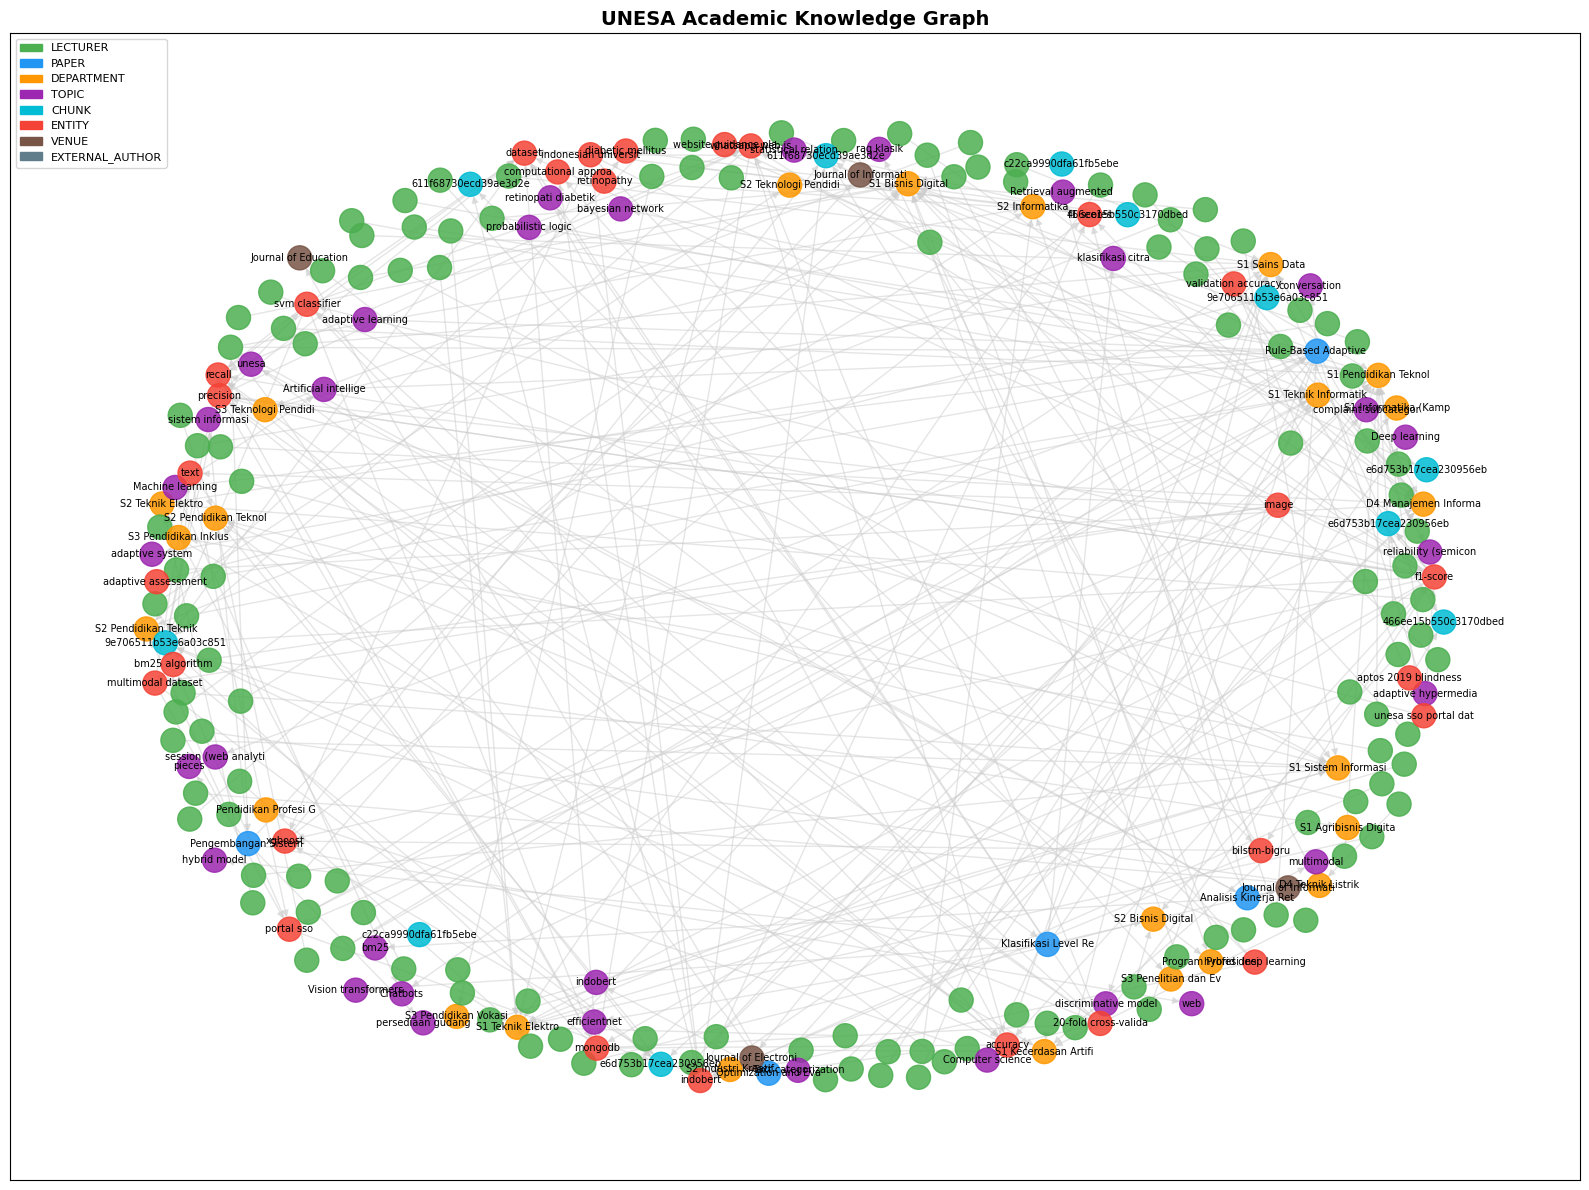

In [9]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx

COLOR_MAP = {'LECTURER':'#4CAF50','PAPER':'#2196F3','DEPARTMENT':'#FF9800','TOPIC':'#9C27B0',
             'CHUNK':'#00BCD4','ENTITY':'#F44336','VENUE':'#795548','EXTERNAL_AUTHOR':'#607D8B'}
G = builder.G
colors = [COLOR_MAP.get(G.nodes[n].get('node_type',''),'#999') for n in G.nodes()]
fig, ax = plt.subplots(1,1,figsize=(16,12))
pos = nx.spring_layout(G, k=2, seed=42)
nx.draw_networkx_nodes(G, pos, node_color=colors, node_size=300, alpha=0.85, ax=ax)
nx.draw_networkx_edges(G, pos, edge_color='#ccc', arrows=True, arrowsize=10, alpha=0.5, ax=ax)
labels = {n: G.nodes[n].get('name', G.nodes[n].get('title', G.nodes[n].get('prefLabel', G.nodes[n].get('label', n.split('/')[-1]))))[:20] for n in G.nodes()}
nx.draw_networkx_labels(G, pos, labels, font_size=7, ax=ax)
ax.legend(handles=[mpatches.Patch(color=c, label=t) for t,c in COLOR_MAP.items()], loc='upper left', fontsize=8)
ax.set_title('UNESA Academic Knowledge Graph', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('kg_visualization.png', dpi=150)
plt.show()

## Cell 10: Export JSON + Neo4j Pre-flight

In [10]:
builder.export_to_json(str(ROOT_DIR / 'kg_export.json'))
print(f'JSON exported: {os.path.getsize(str(ROOT_DIR / "kg_export.json")) / 1024:.1f} KB')

# Neo4j pre-flight
neo4j_ready = False
try:
    from neo4j import GraphDatabase
    uri, user, pw, db = [os.environ.get(k,'') for k in ('NEO4J_URI','NEO4J_USER','NEO4J_PASSWORD','NEO4J_DATABASE')]
    if uri and pw:
        d = GraphDatabase.driver(uri, auth=(user, pw))
        with d.session(database=db) as s: s.run('RETURN 1')
        d.close(); neo4j_ready = True; print('Neo4j: CONNECTED')
except Exception as e:
    print(f'Neo4j: OFFLINE ({e})')
print(f'Neo4j Ready: {neo4j_ready}')

21:06:46 [INFO] graph_builder: Graph exported to JSON: C:\Users\rizky_11yf1be\Desktop\Tugas_Akhir\notebooks\build-graph\kg_export.json


JSON exported: 295.0 KB
Neo4j: OFFLINE (Failed to DNS resolve address 87eb5ce1.databases.neo4j.io:7687: [Errno 11001] getaddrinfo failed)
Neo4j Ready: False


#### Cell 11: Pipeline Summary

In [11]:
print('=' * 60)
print('  UNESA Academic Knowledge Graph - Pipeline Summary')
print('=' * 60)
print(f'  Data       : {len(lecturers)} lecturers, {len(papers)} papers')
print(f'  Nodes      : {builder.G.number_of_nodes()}')
print(f'  Edges      : {builder.G.number_of_edges()}')
print(f'  Neo4j      : {"Connected" if neo4j_ready else "Offline"}')
print('=' * 60)
print(builder.get_summary())

  UNESA Academic Knowledge Graph - Pipeline Summary
  Data       : 129 lecturers, 5 papers
  Nodes      : 233
  Edges      : 279
  Neo4j      : Offline
+==================================================+
|         UNESA Academic Knowledge Graph            |
+==================================================+
|  Total Nodes: 233                                |
|  Total Edges: 279                                |
+--------------------------------------------------+
|  CHUNK             : 11                          |
|  DEPARTMENT        : 24                          |
|  ENTITY            : 28                          |
|  LECTURER          : 129                         |
|  PAPER             : 5                           |
|  TOPIC             : 32                          |
|  VENUE             : 4                           |
+--------------------------------------------------+
|  AUTHORED          : 9                           |
|  BELONGS_TO        : 129                         |